In [4]:
import random
import torch

n = random.randint(2, 6)
iC = random.randint(2, 6)
H = random.randint(10, 20)
W = random.randint(10, 20)
kH = random.randint(2, 5)
kW = random.randint(2, 5)
s = random.randint(2, 3)
input = torch.rand((n, iC, H, W), dtype=torch.float32)

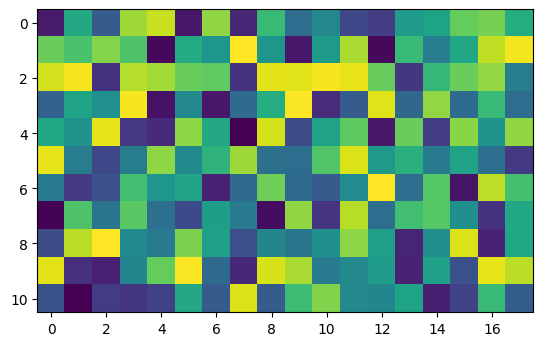

In [5]:
import matplotlib.pyplot as plt

plt.imshow(input[0,0,:,:])

## Solution 1: 4 for loops

In [23]:
# input = (n, iC, H, W)
# (kH, kW)  -> Kernel size
# (s)       -> Stride

# output = (n, iC, oH, oW)

oH = int((input.shape[2] - kH) / s + 1)
oW = int((input.shape[3] - kW) / s + 1)
out = torch.zeros((input.shape[0], input.shape[1], oH, oW)) # (n, iC, oH, oW)
print(f"Output: {out.shape}")

for i in range(input.shape[0]):  # For each image in the batch
    for j in range(input.shape[1]):     # For each channel
        for y in range(oH):
            for x in range(oW):
                ys = y * s
                xs = x * s
                window = input[i, j, ys : (ys + kH), xs : (xs + kW)]
                out[i, j, y, x] = torch.max(window)


Output: torch.Size([5, 5, 3, 6])


## Solution 2: `unfold`

In [24]:
# input = (n, iC, H, W)
# (kH, kW)  -> Kernel size
# (s)       -> Stride

# output = (n, iC, oH, oW)

unfolded = input.unfold(2, kH, s)   # (n, C, oH, W, kH)
unfolded = unfolded.unfold(3, kW, s)    # (n, C, oH, oW, kH, kW)

out = unfolded.flatten(4).max(dim=-1).values

In [11]:
print(f"Input: {input.shape}")
print(f"Kernel shape: ({kH}, {kW})")
print(f"Stride: {s}")

Input: torch.Size([5, 5, 11, 18])
Kernel shape: (5, 2)
Stride: 3
